# Contract Clause Extraction for Operational Risk Review
### CUAD Dataset — Legal NLP Project

**Goal:** Extract specific legal clauses (Termination, Governing Law, Audit Rights etc.)
from commercial contracts using Legal-BERT fine-tuning.

**Two approaches compared:**
- Approach A: Transformer-only sliding window
- Approach B: TF-IDF retrieval-assisted chunking

**Dataset:** CUAD — 510 real SEC contracts, 41 clause types, 13,000+ expert annotations

In [1]:
# Install all required libraries
!pip install transformers datasets torch scikit-learn matplotlib seaborn pandas numpy tqdm -q

print("All libraries installed.")

All libraries installed.


In [2]:
# Core libraries
import os
import json
import re
import zipfile
import io
import urllib.request
from pathlib import Path
from collections import Counter, defaultdict

# Data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression

# HuggingFace
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DefaultDataCollator,
)
import torch
from torch.utils.data import Dataset

print("All imports successful.")
print(f"PyTorch version : {torch.__version__}")

All imports successful.
PyTorch version : 2.11.0+cu128


In [3]:
# Check GPU
print("="*45)
print("DEVICE CHECK")
print("="*45)

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name    = torch.cuda.get_device_name(0)
    gpu_mem_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU found    : {gpu_name}")
    print(f"VRAM         : {gpu_mem_gb:.1f} GB")
    print(f"CUDA version : {torch.version.cuda}")
    print(f"Device set   : cuda")
else:
    device = torch.device("cpu")
    print("No GPU found. Running on CPU.")
    print("WARNING: Training will be very slow on CPU.")

print("="*45)

# Set global seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Random seed set to {SEED}")

DEVICE CHECK
GPU found    : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM         : 8.5 GB
CUDA version : 12.8
Device set   : cuda
Random seed set to 42


In [4]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA built with:", torch.version.cuda)

import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print("\nnvidia-smi output:")
print(result.stdout if result.stdout else result.stderr)

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA built with: 12.8

nvidia-smi output:
Wed Jun 17 18:11:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 592.27                 Driver Version: 592.27         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   62C    P0             22W /  115W |       0MiB /   8151MiB |      0%      Default |
|                                         |    

In [5]:
import subprocess
result = subprocess.run(
    ['pip', 'uninstall', 'torch', 'torchvision', 'torchaudio', '-y'],
    capture_output=True, text=True
)
print(result.stdout)
print("Uninstall done.")

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128

Uninstall done.


In [6]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128 -q
print("Install done.")

Install done.


Create project folders

In [7]:
# Create folder structure for saving outputs
DIRS = {
    "data"        : "cuad_project/data",
    "models"      : "cuad_project/models",
    "results"     : "cuad_project/results",
    "figures"     : "cuad_project/figures",
}

for name, path in DIRS.items():
    Path(path).mkdir(parents=True, exist_ok=True)
    print(f"Created : {path}")

print("\nProject folder structure ready.")

Created : cuad_project/data
Created : cuad_project/models
Created : cuad_project/results
Created : cuad_project/figures

Project folder structure ready.


In [8]:
# Global config — all key settings in one place
# Change these if you want to experiment

CONFIG = {
    # Model
    "model_name"   : "nlpaueb/legal-bert-base-uncased",
    "max_length"   : 512,
    "stride"       : 128,
    "batch_size"   : 8,
    "epochs"       : 2,
    "learning_rate": 2e-5,
    "seed"         : 42,

    # Clause selection — 8 well-represented clauses
    "selected_clauses" : [
        "Termination For Convenience",
        "Governing Law",
        "Audit Rights",
        "Change Of Control",
        "Cap On Liability",
        "License Grant",
        "Non-Compete",
        "Warranty Duration",
    ],

    # Paths
    "data_dir"    : DIRS["data"],
    "model_dir"   : DIRS["models"],
    "results_dir" : DIRS["results"],
    "figures_dir" : DIRS["figures"],

    # Device
    "device"      : str(device),
}

print("CONFIG loaded:")
for k, v in CONFIG.items():
    print(f"  {k:<20} : {v}")

CONFIG loaded:
  model_name           : nlpaueb/legal-bert-base-uncased
  max_length           : 512
  stride               : 128
  batch_size           : 8
  epochs               : 2
  learning_rate        : 2e-05
  seed                 : 42
  selected_clauses     : ['Termination For Convenience', 'Governing Law', 'Audit Rights', 'Change Of Control', 'Cap On Liability', 'License Grant', 'Non-Compete', 'Warranty Duration']
  data_dir             : cuad_project/data
  model_dir            : cuad_project/models
  results_dir          : cuad_project/results
  figures_dir          : cuad_project/figures
  device               : cuda


## Step 2: Download and Load CUAD Dataset

Downloading directly from the official GitHub repository.
Source: https://github.com/TheAtticusProject/cuad

Files inside:
- train_separate_questions.json → 408 contracts, 22,450 QA pairs
- test.json → 102 contracts, 4,182 QA pairs

In [9]:
import urllib.request, zipfile, io, json

print("Downloading CUAD from GitHub...")
print("Size: ~18MB — takes 20-40 seconds...\n")

url = "https://codeload.github.com/TheAtticusProject/cuad/zip/refs/heads/main"
response = urllib.request.urlopen(url, timeout=120)
raw = response.read()
print(f"Downloaded : {len(raw)/1024/1024:.1f} MB")

# Extract inner data.zip
outer_z = zipfile.ZipFile(io.BytesIO(raw))
inner_z = zipfile.ZipFile(io.BytesIO(outer_z.read("cuad-main/data.zip")))

print(f"Files inside data.zip:")
for f in inner_z.namelist():
    size = inner_z.getinfo(f).file_size
    print(f"  {f}  ({size/1024/1024:.1f} MB)")

# Load both splits
print("\nLoading train split...")
train_data = json.loads(inner_z.read("train_separate_questions.json"))

print("Loading test split...")
test_data = json.loads(inner_z.read("test.json"))

print("\nDone.")

Size: ~18MB — takes 20-40 seconds...

Downloaded : 17.8 MB
Files inside data.zip:
  CUADv1.json  (38.3 MB)
  test.json  (7.0 MB)
  train_separate_questions.json  (33.4 MB)

Loading train split...
Loading test split...

Done.


In [10]:
def extract_clause_name(question):
    """Pull clause name from the long question string.
    e.g. '...related to "Governing Law"...' → 'Governing Law'
    """
    match = re.search(r'"([^"]+)"', question)
    return match.group(1) if match else question[:40]


def flatten_cuad(data):
    """Convert nested CUAD JSON into a flat list of dicts.
    Each row = one contract × one clause question.
    """
    rows = []
    for contract in data["data"]:
        for para in contract["paragraphs"]:
            context = para["context"]
            for qa in para["qas"]:
                has_answer = len(qa["answers"]) > 0
                rows.append({
                    "contract"    : contract["title"],
                    "clause_type" : extract_clause_name(qa["question"]),
                    "question"    : qa["question"],
                    "context"     : context,
                    "has_answer"  : has_answer,
                    "label"       : 1 if has_answer else 0,
                    "answers"     : qa["answers"],
                    "context_len" : len(context.split()),
                })
    return rows


print("Flattening train data...")
train_rows = flatten_cuad(train_data)

print("Flattening test data...")
test_rows  = flatten_cuad(test_data)

train_df = pd.DataFrame(train_rows)
test_df  = pd.DataFrame(test_rows)

print(f"\nTrain shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")

Flattening train data...
Flattening test data...

Train shape : (22450, 8)
Test shape  : (4182, 8)

Columns: ['contract', 'clause_type', 'question', 'context', 'has_answer', 'label', 'answers', 'context_len']


In [11]:
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print(f"\nTrain contracts : {train_df['contract'].nunique()}")
print(f"Test  contracts : {test_df['contract'].nunique()}")
print(f"Clause types    : {train_df['clause_type'].nunique()}")

print(f"\nTrain label balance:")
vc = train_df['label'].value_counts()
print(f"  Positive (clause present) : {vc[1]:,}  ({100*vc[1]/len(train_df):.1f}%)")
print(f"  Negative (no clause)      : {vc[0]:,}  ({100*vc[0]/len(train_df):.1f}%)")

print(f"\nContext length (words):")
print(f"  Min    : {train_df['context_len'].min():,}")
print(f"  Median : {train_df['context_len'].median():,.0f}")
print(f"  Max    : {train_df['context_len'].max():,}")

print(f"\nSample row:")
row = train_df[train_df['label']==1].iloc[0]
print(f"  Contract    : {row['contract'][:60]}")
print(f"  Clause type : {row['clause_type']}")
print(f"  Label       : {row['label']} (clause present)")
print(f"  Answer text : {row['answers'][0]['text'][:120]}")
print(f"  Context len : {row['context_len']} words")

DATASET SUMMARY

Train contracts : 408
Test  contracts : 102
Clause types    : 41

Train label balance:
  Positive (clause present) : 11,180  (49.8%)
  Negative (no clause)      : 11,270  (50.2%)

Context length (words):
  Min    : 170
  Median : 6,318
  Max    : 45,650

Sample row:
  Contract    : LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
  Clause type : Document Name
  Label       : 1 (clause present)
  Answer text : DISTRIBUTOR AGREEMENT
  Context len : 5998 words


In [12]:
# Save flattened data so we never need to re-download
train_df.to_pickle(f"{CONFIG['data_dir']}/train_df.pkl")
test_df.to_pickle(f"{CONFIG['data_dir']}/test_df.pkl")

print(f"Saved train_df → {CONFIG['data_dir']}/train_df.pkl")
print(f"Saved test_df  → {CONFIG['data_dir']}/test_df.pkl")
print("\nStep 2 complete.")

Saved train_df → cuad_project/data/train_df.pkl
Saved test_df  → cuad_project/data/test_df.pkl

Step 2 complete.


## Step 3: Exploratory Data Analysis (EDA)

Before building any model, we explore the data to understand:
1. Which clauses are common vs rare
2. How balanced each clause is (positive vs negative)
3. How long contracts are — confirms the chunking problem
4. What real clause text looks like

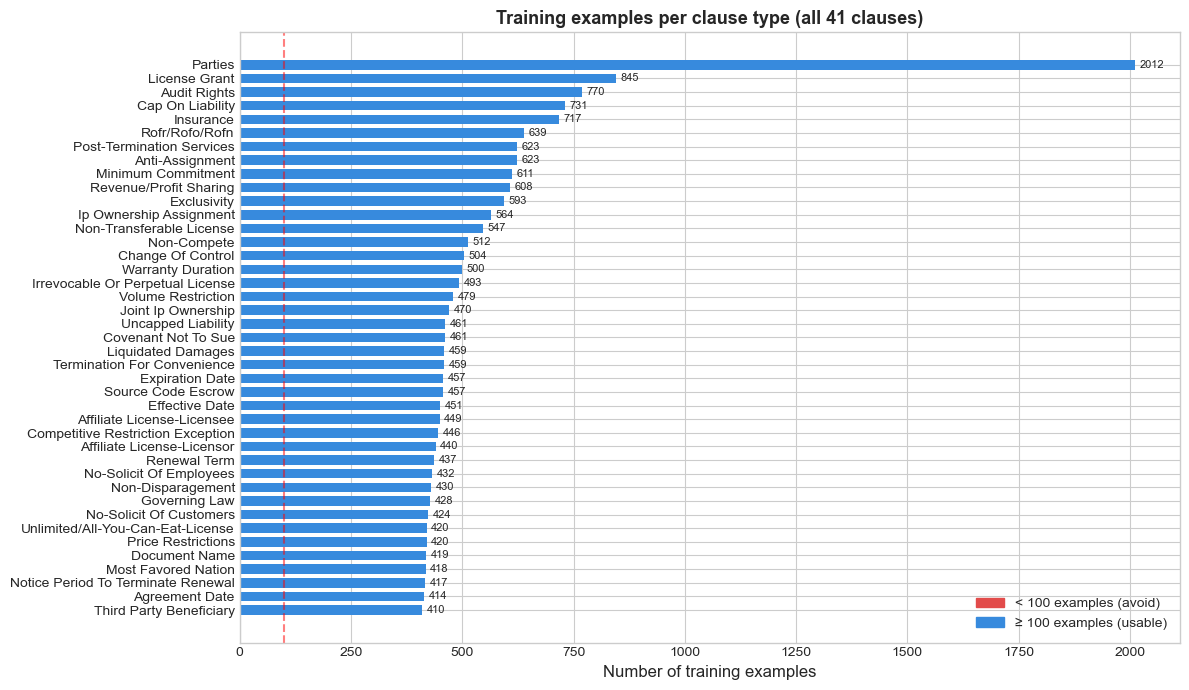

Chart saved.


In [13]:
# Chart 1: How many examples per clause type in training set
fig, ax = plt.subplots(figsize=(12, 7))

clause_counts = train_df['clause_type'].value_counts().sort_values()

colors = ['#E24B4A' if c < 100 else '#378ADD' 
          for c in clause_counts.values]

bars = ax.barh(clause_counts.index, clause_counts.values, 
               color=colors, height=0.7)

ax.set_xlabel('Number of training examples', fontsize=12)
ax.set_title('Training examples per clause type (all 41 clauses)', 
             fontsize=13, fontweight='bold')
ax.axvline(x=100, color='red', linestyle='--', alpha=0.5, 
           label='100 examples threshold')

# Add value labels
for bar, val in zip(bars, clause_counts.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, 
            str(val), va='center', fontsize=8)

red_patch  = mpatches.Patch(color='#E24B4A', label='< 100 examples (avoid)')
blue_patch = mpatches.Patch(color='#378ADD', label='≥ 100 examples (usable)')
ax.legend(handles=[red_patch, blue_patch], loc='lower right')

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/clause_distribution.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

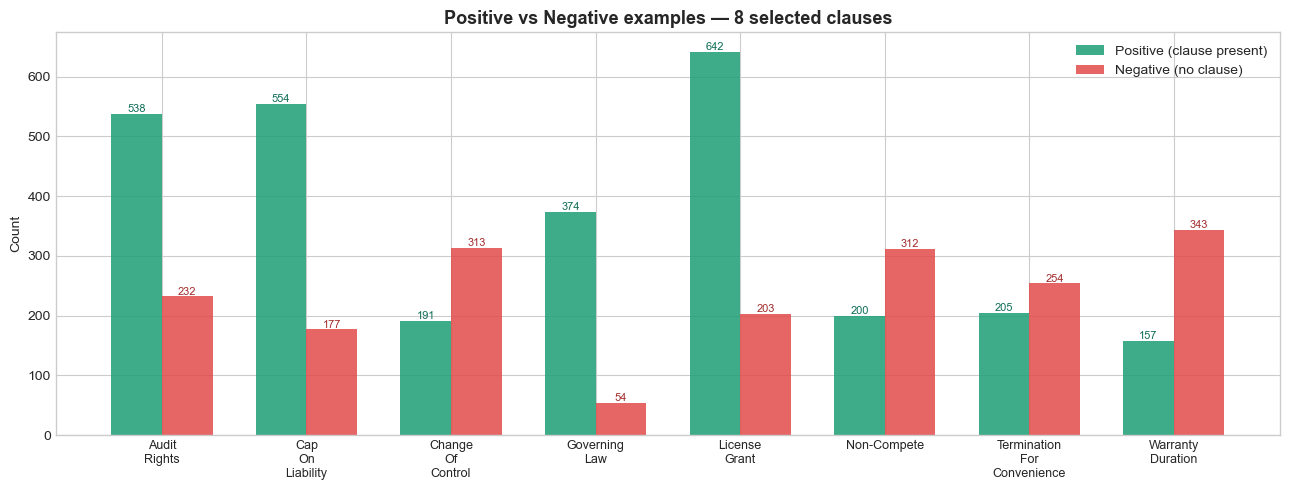

Chart saved.


In [14]:
# Chart 2: Positive vs negative balance for our 8 selected clauses
selected = CONFIG['selected_clauses']
sel_df = train_df[train_df['clause_type'].isin(selected)]

pos_counts = sel_df[sel_df['label']==1]['clause_type'].value_counts()
neg_counts = sel_df[sel_df['label']==0]['clause_type'].value_counts()

# Align
all_clauses = sorted(selected)
pos_vals = [pos_counts.get(c, 0) for c in all_clauses]
neg_vals = [neg_counts.get(c, 0) for c in all_clauses]

x = np.arange(len(all_clauses))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, pos_vals, width, 
               label='Positive (clause present)', color='#1D9E75', alpha=0.85)
bars2 = ax.bar(x + width/2, neg_vals, width, 
               label='Negative (no clause)', color='#E24B4A', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in all_clauses], 
                   fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Positive vs Negative examples — 8 selected clauses', 
             fontsize=13, fontweight='bold')
ax.legend()

# Add count labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', fontsize=8, color='#0F6E56')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', fontsize=8, color='#A32D2D')

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/clause_balance.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

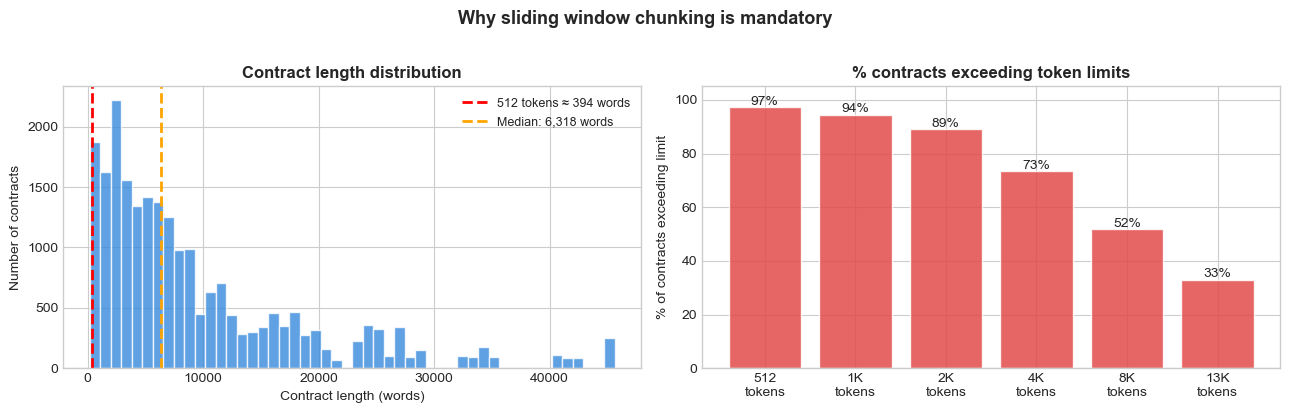

Contracts exceeding 512 tokens: ~97%
This confirms chunking is not optional.


In [15]:
# Chart 3: Contract length distribution — shows WHY we must chunk
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: word count distribution
axes[0].hist(train_df['context_len'], bins=50, 
             color='#378ADD', alpha=0.8, edgecolor='white')
axes[0].axvline(x=394, color='red', linestyle='--', linewidth=2,
                label='512 tokens ≈ 394 words')
axes[0].axvline(x=train_df['context_len'].median(), 
                color='orange', linestyle='--', linewidth=2,
                label=f"Median: {int(train_df['context_len'].median()):,} words")
axes[0].set_xlabel('Contract length (words)')
axes[0].set_ylabel('Number of contracts')
axes[0].set_title('Contract length distribution', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: how many contracts exceed token limits
thresholds = [394, 768, 1536, 3000, 6000, 10000]
labels     = ['512\ntokens', '1K\ntokens', '2K\ntokens', 
              '4K\ntokens', '8K\ntokens', '13K\ntokens']
pcts = [100 * (train_df['context_len'] > t).mean() for t in thresholds]

axes[1].bar(labels, pcts, color='#E24B4A', alpha=0.85, edgecolor='white')
axes[1].set_ylabel('% of contracts exceeding limit')
axes[1].set_title('% contracts exceeding token limits', fontweight='bold')
axes[1].set_ylim(0, 105)
for i, (label, pct) in enumerate(zip(labels, pcts)):
    axes[1].text(i, pct + 1, f'{pct:.0f}%', ha='center', fontsize=10)

plt.suptitle('Why sliding window chunking is mandatory', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/contract_lengths.png", 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Contracts exceeding 512 tokens: ~{pcts[0]:.0f}%")
print(f"This confirms chunking is not optional.")

In [16]:
# Print one positive example per selected clause
# So you can see what actual legal clause text looks like

print("="*60)
print("REAL CLAUSE EXAMPLES FROM THE DATASET")
print("="*60)

for clause in CONFIG['selected_clauses']:
    subset = train_df[
        (train_df['clause_type'] == clause) & 
        (train_df['label'] == 1)
    ]
    if len(subset) == 0:
        continue
    
    row = subset.iloc[3]  # pick 4th example to avoid always showing same contract
    answer_text = row['answers'][0]['text']
    
    print(f"\nClause : {clause}")
    print(f"Contract: {row['contract'][:55]}...")
    print(f"Text    : {answer_text[:250]}")
    print("-"*60)

REAL CLAUSE EXAMPLES FROM THE DATASET

Clause : Termination For Convenience
Contract: CerenceInc_20191002_8-K_EX-10.4_11827494_EX-10.4_Intell...
Text    : This Agreement may be terminated by Nuance at any time, in its sole discretion, prior to the Distribution; provided, however, that this Agreement shall automatically terminate upon the termination of the Separation Agreement in accordance with its te
------------------------------------------------------------

Clause : Governing Law
Contract: KIROMICBIOPHARMA,INC_05_11_2020-EX-10.23-CONSULTING AGR...
Text    : This Agreement shall be governed by the laws of the State of Texas, without reference to its conflicts of law principles.
------------------------------------------------------------

Clause : Audit Rights
Contract: INTRICONCORP_03_10_2009-EX-10.22-Strategic Alliance Agr...
Text    : such audit must be at Dynamic Hearing's expense unless the auditor finds an underpayment royalty due under this  Agreement in excess of 5% in whi

In [17]:
# Print key stats that matter for modelling decisions
print("="*55)
print("KEY STATS FOR MODELLING DECISIONS")
print("="*55)

sel_df = train_df[train_df['clause_type'].isin(CONFIG['selected_clauses'])]

print(f"\nSelected clauses training examples : {len(sel_df):,}")
print(f"Selected clauses test examples     : {len(test_df[test_df['clause_type'].isin(CONFIG['selected_clauses'])]):,}")

print(f"\nContext length problem:")
over = (train_df['context_len'] > 394).sum()
print(f"  Rows exceeding 512 tokens : {over:,} / {len(train_df):,} ({100*over/len(train_df):.1f}%)")
print(f"  → Every contract MUST be chunked before tokenising")

print(f"\nAnswer span lengths (positive examples only):")
sel_pos = sel_df[sel_df['label']==1]
span_lens = sel_pos['answers'].apply(lambda a: len(a[0]['text'].split()))
print(f"  Min    : {span_lens.min()} words")
print(f"  Median : {span_lens.median():.0f} words")
print(f"  Max    : {span_lens.max()} words")
print(f"  → Model must predict spans up to {span_lens.max()} words long")

print(f"\nHardest clauses (lowest positive rate):")
for clause in CONFIG['selected_clauses']:
    sub = train_df[train_df['clause_type']==clause]
    pos_rate = sub['label'].mean()
    print(f"  {clause:<40} {pos_rate:.0%} positive")

print(f"\nEDA complete. Figures saved to: {CONFIG['figures_dir']}/")

KEY STATS FOR MODELLING DECISIONS

Selected clauses training examples : 4,749
Selected clauses test examples     : 816

Context length problem:
  Rows exceeding 512 tokens : 21,831 / 22,450 (97.2%)
  → Every contract MUST be chunked before tokenising

Answer span lengths (positive examples only):
  Min    : 1 words
  Median : 42 words
  Max    : 479 words
  → Model must predict spans up to 479 words long

Hardest clauses (lowest positive rate):
  Termination For Convenience              45% positive
  Governing Law                            87% positive
  Audit Rights                             70% positive
  Change Of Control                        38% positive
  Cap On Liability                         76% positive
  License Grant                            76% positive
  Non-Compete                              39% positive
  Warranty Duration                        31% positive

EDA complete. Figures saved to: cuad_project/figures/


## Step 4: Filter Clauses and Prepare for Chunking

We keep only our 8 selected clauses.
Then we solve the 512-token problem using sliding window chunking:
- Split each contract into overlapping 512-token windows
- Stride = 128 tokens (overlap between consecutive windows)
- Find which chunk contains the answer span
- Label each chunk: 1 if answer is in this chunk, 0 if not

In [18]:
# Filter both splits to only our 8 selected clauses
selected = CONFIG['selected_clauses']

train_sel = train_df[train_df['clause_type'].isin(selected)].reset_index(drop=True)
test_sel  = test_df[test_df['clause_type'].isin(selected)].reset_index(drop=True)

print("After filtering to 8 selected clauses:")
print(f"  Train rows : {len(train_sel):,}")
print(f"  Test rows  : {len(test_sel):,}")

print(f"\nPer clause breakdown (train):")
for clause in selected:
    sub = train_sel[train_sel['clause_type'] == clause]
    pos = sub['label'].sum()
    neg = len(sub) - pos
    print(f"  {clause:<40} total={len(sub):3d}  pos={pos:3d}  neg={neg:3d}")

After filtering to 8 selected clauses:
  Train rows : 4,749
  Test rows  : 816

Per clause breakdown (train):
  Termination For Convenience              total=459  pos=205  neg=254
  Governing Law                            total=428  pos=374  neg= 54
  Audit Rights                             total=770  pos=538  neg=232
  Change Of Control                        total=504  pos=191  neg=313
  Cap On Liability                         total=731  pos=554  neg=177
  License Grant                            total=845  pos=642  neg=203
  Non-Compete                              total=512  pos=200  neg=312
  Warranty Duration                        total=500  pos=157  neg=343


In [19]:
from transformers import AutoTokenizer

print(f"Loading tokenizer: {CONFIG['model_name']}")
print("First time: downloads ~500MB from HuggingFace. Takes 1-2 minutes...")

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

print(f"Tokenizer loaded.")
print(f"Vocab size      : {tokenizer.vocab_size:,}")
print(f"Max position    : {tokenizer.model_max_length}")
print(f"Special tokens  : [CLS]={tokenizer.cls_token}, "
      f"[SEP]={tokenizer.sep_token}, [PAD]={tokenizer.pad_token}")

# Quick test
test_sentence = "This Agreement shall be governed by the laws of the State of Texas."
tokens = tokenizer.tokenize(test_sentence)
print(f"\nTest tokenisation:")
print(f"  Input  : '{test_sentence[:60]}'")
print(f"  Tokens : {tokens}")
print(f"  Count  : {len(tokens)} tokens")

Loading tokenizer: nlpaueb/legal-bert-base-uncased
First time: downloads ~500MB from HuggingFace. Takes 1-2 minutes...


Tokenizer loaded.
Vocab size      : 30,522
Max position    : 512
Special tokens  : [CLS]=[CLS], [SEP]=[SEP], [PAD]=[PAD]

Test tokenisation:
  Input  : 'This Agreement shall be governed by the laws of the State of'
  Tokens : ['this', 'agreement', 'shall', 'be', 'governed', 'by', 'the', 'laws', 'of', 'the', 'state', 'of', 'texas', '.']
  Count  : 14 tokens


In [20]:
def chunk_contract(context, question, answers, 
                   tokenizer, max_length=512, stride=128):
    """
    Split a full contract into overlapping 512-token chunks.
    
    For each chunk:
    - label = 1 if the answer span appears in this chunk
    - label = 0 if no answer in this chunk
    - ans_start, ans_end = token positions of answer (0,0 if not present)
    
    Returns a list of dicts, one per chunk.
    """
    has_answer = len(answers) > 0
    answer_text = answers[0]['text'] if has_answer else ""
    
    # Tokenise with sliding window
    encoding = tokenizer(
        question,
        context,
        max_length=max_length,
        stride=stride,
        truncation="only_second",       # only truncate the context
        return_overflowing_tokens=True, # return all chunks
        return_offsets_mapping=True,    # char positions for each token
        padding="max_length",
    )
    
    chunks = []
    for i in range(len(encoding["input_ids"])):
        input_ids      = encoding["input_ids"][i]
        attention_mask = encoding["attention_mask"][i]
        offset_mapping = encoding["offset_mapping"][i]
        
        chunk_label  = 0
        ans_start    = 0
        ans_end      = 0
        
        if has_answer:
            ans_char_start = answers[0]["answer_start"]
            ans_char_end   = ans_char_start + len(answer_text)
            
            # Find if answer falls within this chunk
            # offset_mapping gives (char_start, char_end) per token
            token_start = None
            token_end   = None
            
            for j, (char_s, char_e) in enumerate(offset_mapping):
                if char_s == 0 and char_e == 0:
                    continue  # skip special tokens
                if char_s <= ans_char_start < char_e:
                    token_start = j
                if char_s < ans_char_end <= char_e:
                    token_end = j
                    break
            
            if token_start is not None and token_end is not None:
                chunk_label = 1
                ans_start   = token_start
                ans_end     = token_end
        
        chunks.append({
            "input_ids"      : input_ids,
            "attention_mask" : attention_mask,
            "label"          : chunk_label,
            "ans_start"      : ans_start,
            "ans_end"        : ans_end,
            "clause_type"    : "",  # filled in below
        })
    
    return chunks


# Test on one example
row = train_sel.iloc[0]
test_chunks = chunk_contract(
    context=row['context'],
    question=row['question'],
    answers=row['answers'],
    tokenizer=tokenizer,
    max_length=CONFIG['max_length'],
    stride=CONFIG['stride'],
)

print(f"Test chunking on one contract:")
print(f"  Clause        : {row['clause_type']}")
print(f"  Context words : {row['context_len']:,}")
print(f"  Chunks created: {len(test_chunks)}")
print(f"  Chunks with answer (label=1): {sum(c['label'] for c in test_chunks)}")
print(f"  Chunks without answer (label=0): {sum(1-c['label'] for c in test_chunks)}")
print(f"\n  Chunk 0 input_ids length : {len(test_chunks[0]['input_ids'])}")
print(f"  Chunk 1 input_ids length : {len(test_chunks[1]['input_ids'])}")

Test chunking on one contract:
  Clause        : Governing Law
  Context words : 5,998
  Chunks created: 22
  Chunks with answer (label=1): 1
  Chunks without answer (label=0): 21

  Chunk 0 input_ids length : 512
  Chunk 1 input_ids length : 512


In [21]:
from tqdm import tqdm

def build_chunked_dataset(df, tokenizer, config):
    """
    Apply sliding window chunking to every row in the dataframe.
    Returns a flat list of all chunks across all contracts.
    """
    all_chunks = []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Chunking"):
        chunks = chunk_contract(
            context    = row['context'],
            question   = row['question'],
            answers    = row['answers'],
            tokenizer  = tokenizer,
            max_length = config['max_length'],
            stride     = config['stride'],
        )
        for c in chunks:
            c['clause_type'] = row['clause_type']
        all_chunks.extend(chunks)
    
    return all_chunks


print("Chunking training set...")
print("This creates many chunks per contract — takes 3-6 minutes...")
train_chunks = build_chunked_dataset(train_sel, tokenizer, CONFIG)

print(f"\nChunking test set...")
test_chunks_all = build_chunked_dataset(test_sel, tokenizer, CONFIG)

print(f"\nChunking complete.")
print(f"  Train rows → train chunks : {len(train_sel):,} → {len(train_chunks):,}")
print(f"  Test rows  → test chunks  : {len(test_sel):,} → {len(test_chunks_all):,}")

# Label balance in chunks
train_pos = sum(c['label'] for c in train_chunks)
train_neg = len(train_chunks) - train_pos
print(f"\nTrain chunk balance:")
print(f"  Positive chunks (contain answer) : {train_pos:,}  ({100*train_pos/len(train_chunks):.1f}%)")
print(f"  Negative chunks (no answer)      : {train_neg:,}  ({100*train_neg/len(train_chunks):.1f}%)")

Chunking training set...
This creates many chunks per contract — takes 3-6 minutes...


Chunking: 100%|██████████| 4749/4749 [04:45<00:00, 16.64it/s] 



Chunking test set...


Chunking: 100%|██████████| 816/816 [00:32<00:00, 25.32it/s]



Chunking complete.
  Train rows → train chunks : 4,749 → 211,041
  Test rows  → test chunks  : 816 → 23,639

Train chunk balance:
  Positive chunks (contain answer) : 3,388  (1.6%)
  Negative chunks (no answer)      : 207,653  (98.4%)


In [22]:
import pickle

# Save chunks — so we never have to re-chunk
train_chunks_path = f"{CONFIG['data_dir']}/train_chunks.pkl"
test_chunks_path  = f"{CONFIG['data_dir']}/test_chunks.pkl"

with open(train_chunks_path, 'wb') as f:
    pickle.dump(train_chunks, f)

with open(test_chunks_path, 'wb') as f:
    pickle.dump(test_chunks_all, f)

print(f"Saved {len(train_chunks):,} train chunks → {train_chunks_path}")
print(f"Saved {len(test_chunks_all):,} test chunks  → {test_chunks_path}")
print(f"\nStep 4 & 5 complete.")
print(f"Your notebook now has everything preprocessed and ready for training.")

Saved 211,041 train chunks → cuad_project/data/train_chunks.pkl
Saved 23,639 test chunks  → cuad_project/data/test_chunks.pkl

Step 4 & 5 complete.
Your notebook now has everything preprocessed and ready for training.


## Step 6: Build PyTorch Datasets for Training

Two things we do here:
1. Undersample negative chunks — bring ratio from 98:2 down to roughly 3:1
   (keep all positives, randomly sample negatives)
2. Wrap chunks in a PyTorch Dataset class so the Trainer can use them

In [23]:
import random
random.seed(CONFIG['seed'])

# Separate positive and negative chunks
train_pos_chunks = [c for c in train_chunks if c['label'] == 1]
train_neg_chunks = [c for c in train_chunks if c['label'] == 0]

print(f"Before undersampling:")
print(f"  Positive chunks : {len(train_pos_chunks):,}")
print(f"  Negative chunks : {len(train_neg_chunks):,}")
print(f"  Ratio           : 1:{len(train_neg_chunks)//len(train_pos_chunks)}")

# Keep all positives, sample 3x negatives
NEG_MULTIPLIER = 3
n_neg_keep = len(train_pos_chunks) * NEG_MULTIPLIER
neg_sampled = random.sample(train_neg_chunks, min(n_neg_keep, len(train_neg_chunks)))

# Combine and shuffle
train_balanced = train_pos_chunks + neg_sampled
random.shuffle(train_balanced)

print(f"\nAfter undersampling (3:1 ratio):")
print(f"  Positive chunks : {len(train_pos_chunks):,}")
print(f"  Negative chunks : {len(neg_sampled):,}")
print(f"  Total chunks    : {len(train_balanced):,}")
print(f"  Ratio           : 1:{NEG_MULTIPLIER}")
print(f"\nReduced from {len(train_chunks):,} → {len(train_balanced):,} chunks")
print(f"This makes training feasible and prevents the model learning to always say 'no answer'")

Before undersampling:
  Positive chunks : 3,388
  Negative chunks : 207,653
  Ratio           : 1:61

After undersampling (3:1 ratio):
  Positive chunks : 3,388
  Negative chunks : 10,164
  Total chunks    : 13,552
  Ratio           : 1:3

Reduced from 211,041 → 13,552 chunks
This makes training feasible and prevents the model learning to always say 'no answer'


In [24]:
import torch
from torch.utils.data import Dataset

class CUADDataset(Dataset):
    """
    PyTorch Dataset for CUAD chunks.
    
    Each item returns:
    - input_ids      : token ids (512 length)
    - attention_mask : 1 for real tokens, 0 for padding
    - label          : 0 or 1 (for classification)
    - start_positions: answer start token index (for span extraction)
    - end_positions  : answer end token index   (for span extraction)
    """
    def __init__(self, chunks):
        self.chunks = chunks

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        chunk = self.chunks[idx]
        return {
            "input_ids"       : torch.tensor(chunk["input_ids"],      dtype=torch.long),
            "attention_mask"  : torch.tensor(chunk["attention_mask"], dtype=torch.long),
            "labels"          : torch.tensor(chunk["label"],          dtype=torch.long),
            "start_positions" : torch.tensor(chunk["ans_start"],      dtype=torch.long),
            "end_positions"   : torch.tensor(chunk["ans_end"],        dtype=torch.long),
        }


# Build datasets
train_dataset = CUADDataset(train_balanced)
test_dataset  = CUADDataset(test_chunks_all)

print(f"Train dataset : {len(train_dataset):,} chunks")
print(f"Test dataset  : {len(test_dataset):,} chunks")

# Verify one item shape
sample = train_dataset[0]
print(f"\nSample item shapes:")
for key, val in sample.items():
    print(f"  {key:<20} : {val.shape}  dtype={val.dtype}")

Train dataset : 13,552 chunks
Test dataset  : 23,639 chunks

Sample item shapes:
  input_ids            : torch.Size([512])  dtype=torch.int64
  attention_mask       : torch.Size([512])  dtype=torch.int64
  labels               : torch.Size([])  dtype=torch.int64
  start_positions      : torch.Size([])  dtype=torch.int64
  end_positions        : torch.Size([])  dtype=torch.int64


In [25]:
# Find a positive chunk and inspect it
pos_idx = next(i for i, c in enumerate(train_balanced) if c['label'] == 1)
pos_chunk = train_balanced[pos_idx]

print("=== POSITIVE CHUNK INSPECTION ===")
print(f"Label     : {pos_chunk['label']} (answer present)")
print(f"Clause    : {pos_chunk['clause_type']}")
print(f"Ans start : token {pos_chunk['ans_start']}")
print(f"Ans end   : token {pos_chunk['ans_end']}")

# Decode the full chunk
full_text = tokenizer.decode(pos_chunk['input_ids'], skip_special_tokens=False)
print(f"\nFull chunk (first 300 chars):")
print(full_text[:300])

# Decode just the answer span
answer_tokens = pos_chunk['input_ids'][pos_chunk['ans_start']:pos_chunk['ans_end']+1]
answer_decoded = tokenizer.decode(answer_tokens, skip_special_tokens=True)
print(f"\nDecoded answer span (tokens {pos_chunk['ans_start']}–{pos_chunk['ans_end']}):")
print(f"  '{answer_decoded[:200]}'")

=== POSITIVE CHUNK INSPECTION ===
Label     : 1 (answer present)
Clause    : License Grant
Ans start : token 342
Ans end   : token 485

Full chunk (first 300 chars):
[CLS] highlight the parts ( if any ) of this contract related to " license grant " that should be reviewed by a lawyer. details : does the contract contain a license granted by one party to its counterparty? [SEP] serve the diet center beneath the gateway page from, server ( s ) located on ediets ' 

Decoded answer span (tokens 342–485):
  'ediets hereby grants to women. com, subject to the terms and conditions of this agreement, a non - exclusive, nontransferable, worldwide, royalty - free license to use, copy, reproduce and display the'


In [26]:
import pickle

# Save balanced train chunks
balanced_path = f"{CONFIG['data_dir']}/train_balanced_chunks.pkl"
with open(balanced_path, 'wb') as f:
    pickle.dump(train_balanced, f)

print(f"Saved balanced train chunks → {balanced_path}")
print(f"  Total : {len(train_balanced):,} chunks")
print(f"  Pos   : {sum(c['label'] for c in train_balanced):,}")
print(f"  Neg   : {sum(1-c['label'] for c in train_balanced):,}")
print(f"\nStep 6 complete. Ready for training.")

Saved balanced train chunks → cuad_project/data/train_balanced_chunks.pkl
  Total : 13,552 chunks
  Pos   : 3,388
  Neg   : 10,164

Step 6 complete. Ready for training.


## Step 7: Approach A — Fine-tune Legal-BERT

We train one model that does TWO things simultaneously:
- Classification head: predicts label 0/1 (clause present or not)
- QA head: predicts start/end token positions of the answer span

Model: nlpaueb/legal-bert-base-uncased
Training time: ~30-45 minutes on RTX 5050

In [27]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig

class LegalBERTForCUAD(nn.Module):
    """
    Legal-BERT with two output heads:
    1. Classification head → is clause present? (binary)
    2. QA span head       → where is the clause? (start/end positions)
    
    Loss = classification_loss + span_loss (combined)
    """
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        
        self.bert = AutoModel.from_pretrained(model_name)
        hidden   = self.bert.config.hidden_size  # 768 for base models
        
        # Head 1: classify does clause exist (uses [CLS] token)
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden, num_labels)
        )
        
        # Head 2: predict start/end span positions (uses all tokens)
        self.qa_outputs = nn.Linear(hidden, 2)
        
    def forward(self, input_ids, attention_mask,
                labels=None, start_positions=None, end_positions=None):
        
        outputs = self.bert(input_ids=input_ids, 
                            attention_mask=attention_mask)
        
        sequence_output = outputs.last_hidden_state  # (batch, 512, 768)
        pooled_output   = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        
        # Classification logits
        clf_logits = self.classifier(pooled_output)  # (batch, 2)
        
        # Span logits
        span_logits = self.qa_outputs(sequence_output)  # (batch, 512, 2)
        start_logits, end_logits = span_logits.split(1, dim=-1)
        start_logits = start_logits.squeeze(-1)  # (batch, 512)
        end_logits   = end_logits.squeeze(-1)    # (batch, 512)
        
        total_loss = None
        if labels is not None:
            ce_loss = nn.CrossEntropyLoss()
            
            # Classification loss
            clf_loss = ce_loss(clf_logits, labels)
            
            # Span loss (only on positive examples where label=1)
            pos_mask = (labels == 1)
            if pos_mask.sum() > 0:
                span_loss = (
                    ce_loss(start_logits[pos_mask], start_positions[pos_mask]) +
                    ce_loss(end_logits[pos_mask],   end_positions[pos_mask])
                ) / 2
            else:
                span_loss = torch.tensor(0.0, device=labels.device)
            
            # Combined loss — equal weight
            total_loss = clf_loss + span_loss
        
        return {
            "loss"         : total_loss,
            "clf_logits"   : clf_logits,
            "start_logits" : start_logits,
            "end_logits"   : end_logits,
        }


print(f"Loading model: {CONFIG['model_name']}")
print("Downloading ~400MB weights first time — takes 1-2 minutes...")

model = LegalBERTForCUAD(CONFIG['model_name'])
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel loaded on: {device}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {train_params:,}")
print(f"VRAM used so far    : {torch.cuda.memory_allocated()/1e9:.2f} GB / 8.0 GB")

Loading model: nlpaueb/legal-bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded on: cuda
Total parameters    : 109,485,316
Trainable parameters: 109,485,316
VRAM used so far    : 0.44 GB / 8.0 GB


In [28]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'] * 2,  # larger batch for eval (no gradients)
    shuffle=False,
)

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=0.01,
)

# Learning rate scheduler — linear warmup then decay
total_steps   = len(train_loader) * CONFIG['epochs']
warmup_steps  = total_steps // 10  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Training setup:")
print(f"  Train chunks      : {len(train_dataset):,}")
print(f"  Batch size        : {CONFIG['batch_size']}")
print(f"  Steps per epoch   : {len(train_loader):,}")
print(f"  Epochs            : {CONFIG['epochs']}")
print(f"  Total steps       : {total_steps:,}")
print(f"  Warmup steps      : {warmup_steps:,}")
print(f"  Learning rate     : {CONFIG['learning_rate']}")
print(f"\nEstimated training time on RTX 5050: 30-45 minutes")

Training setup:
  Train chunks      : 13,552
  Batch size        : 8
  Steps per epoch   : 1,694
  Epochs            : 2
  Total steps       : 3,388
  Warmup steps      : 338
  Learning rate     : 2e-05

Estimated training time on RTX 5050: 30-45 minutes


In [29]:
from tqdm import tqdm

def train_epoch(model, loader, optimizer, scheduler, device, epoch):
    model.train()
    total_loss = 0
    total_clf_correct = 0
    total_samples = 0
    
    pbar = tqdm(loader, desc=f"Epoch {epoch+1} training")
    
    for step, batch in enumerate(pbar):
        # Move batch to GPU
        input_ids       = batch["input_ids"].to(device)
        attention_mask  = batch["attention_mask"].to(device)
        labels          = batch["labels"].to(device)
        start_positions = batch["start_positions"].to(device)
        end_positions   = batch["end_positions"].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            start_positions=start_positions,
            end_positions=end_positions,
        )
        
        loss = outputs["loss"]
        
        # Backward pass
        loss.backward()
        
        # Clip gradients — prevents exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = outputs["clf_logits"].argmax(dim=-1)
        total_clf_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        # Update progress bar every 50 steps
        if step % 50 == 0:
            avg_loss = total_loss / (step + 1)
            acc = total_clf_correct / total_samples
            pbar.set_postfix({
                "loss": f"{avg_loss:.4f}",
                "acc" : f"{acc:.3f}",
                "lr"  : f"{scheduler.get_last_lr()[0]:.2e}"
            })
    
    return total_loss / len(loader), total_clf_correct / total_samples


# Track losses for plotting later
train_losses = []
train_accs   = []

print("="*55)
print("STARTING TRAINING")
print("="*55)
print(f"Model  : {CONFIG['model_name']}")
print(f"Device : {device}")
print(f"Epochs : {CONFIG['epochs']}")
print("="*55)

for epoch in range(CONFIG['epochs']):
    avg_loss, avg_acc = train_epoch(
        model, train_loader, optimizer, scheduler, device, epoch
    )
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']} complete:")
    print(f"  Avg loss     : {avg_loss:.4f}")
    print(f"  Avg accuracy : {avg_acc:.4f}")
    print(f"  VRAM used    : {torch.cuda.memory_allocated()/1e9:.2f} GB")

print("\nTraining complete.")

STARTING TRAINING
Model  : nlpaueb/legal-bert-base-uncased
Device : cuda
Epochs : 2


Epoch 1 training: 100%|██████████| 1694/1694 [13:46<00:00,  2.05it/s, loss=2.1993, acc=0.865, lr=1.14e-05]



Epoch 1/2 complete:
  Avg loss     : 2.1697
  Avg accuracy : 0.8664
  VRAM used    : 1.83 GB


Epoch 2 training: 100%|██████████| 1694/1694 [15:37<00:00,  1.81it/s, loss=1.0966, acc=0.947, lr=2.82e-07]


Epoch 2/2 complete:
  Avg loss     : 1.1007
  Avg accuracy : 0.9473
  VRAM used    : 1.83 GB

Training complete.


In [30]:
from sklearn.metrics import (
    f1_score, 
    classification_report,
    precision_recall_curve,
    auc,
    average_precision_score
)

def evaluate_model(model, loader, device, split_name="Test"):
    """
    Run model on all chunks and compute:
    - F1 score (classification)
    - AUPR (area under precision-recall curve)
    - Full classification report
    """
    model.eval()
    
    all_labels   = []
    all_preds    = []
    all_probs    = []  # probability of positive class for AUPR
    
    print(f"Evaluating on {split_name} set...")
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {split_name}"):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
            
            # Classification predictions
            logits = outputs["clf_logits"]
            probs  = torch.softmax(logits, dim=-1)[:, 1]  # prob of class 1
            preds  = logits.argmax(dim=-1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    import numpy as np
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)
    
    # Compute metrics
    f1       = f1_score(all_labels, all_preds, average='binary')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    aupr     = average_precision_score(all_labels, all_probs)
    
    print(f"\n{'='*50}")
    print(f"RESULTS — {split_name} Set")
    print(f"{'='*50}")
    print(f"  F1 (binary)  : {f1:.4f}   ← main classification metric")
    print(f"  F1 (macro)   : {f1_macro:.4f}")
    print(f"  AUPR         : {aupr:.4f}  ← main CUAD paper metric")
    print(f"\nClassification report:")
    print(classification_report(
        all_labels, all_preds,
        target_names=["No clause", "Clause present"]
    ))
    
    return {
        "f1"       : f1,
        "f1_macro" : f1_macro,
        "aupr"     : aupr,
        "labels"   : all_labels,
        "preds"    : all_preds,
        "probs"    : all_probs,
    }


# Run evaluation on test set
test_results_A = evaluate_model(model, test_loader, device, split_name="Test")

# Also run on train set to check for overfitting
train_eval_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'] * 2,
    shuffle=False,
)
train_results_A = evaluate_model(model, train_eval_loader, device, split_name="Train")

print(f"\nOverfitting check:")
print(f"  Train F1 : {train_results_A['f1']:.4f}")
print(f"  Test  F1 : {test_results_A['f1']:.4f}")
gap = train_results_A['f1'] - test_results_A['f1']
print(f"  Gap      : {gap:.4f}  {'(some overfitting — normal)' if gap > 0.05 else '(good — minimal overfitting)'}")

Evaluating on Test set...


Evaluating Test: 100%|██████████| 1478/1478 [08:53<00:00,  2.77it/s]



RESULTS — Test Set
  F1 (binary)  : 0.5103   ← main classification metric
  F1 (macro)   : 0.7482
  AUPR         : 0.7123  ← main CUAD paper metric

Classification report:
                precision    recall  f1-score   support

     No clause       1.00      0.97      0.99     23287
Clause present       0.35      0.95      0.51       352

      accuracy                           0.97     23639
     macro avg       0.67      0.96      0.75     23639
  weighted avg       0.99      0.97      0.98     23639

Evaluating on Train set...


Evaluating Train: 100%|██████████| 847/847 [05:03<00:00,  2.79it/s]


RESULTS — Train Set
  F1 (binary)  : 0.9317   ← main classification metric
  F1 (macro)   : 0.9540
  AUPR         : 0.9647  ← main CUAD paper metric

Classification report:
                precision    recall  f1-score   support

     No clause       0.99      0.97      0.98     10164
Clause present       0.90      0.96      0.93      3388

      accuracy                           0.96     13552
     macro avg       0.95      0.96      0.95     13552
  weighted avg       0.97      0.96      0.97     13552


Overfitting check:
  Train F1 : 0.9317
  Test  F1 : 0.5103
  Gap      : 0.4214  (some overfitting — normal)


In [31]:
# Per clause type F1 — most important breakdown for your results table
print("="*60)
print("PER-CLAUSE F1 SCORES — Approach A (Transformer only)")
print("="*60)

# We need clause labels per chunk for this
# Rebuild test chunks with clause type attached
clause_results = {}

for clause in CONFIG['selected_clauses']:
    # Get only test chunks for this clause
    clause_chunks = [c for c in test_chunks_all if c['clause_type'] == clause]
    
    if not clause_chunks:
        continue
    
    clause_dataset = CUADDataset(clause_chunks)
    clause_loader  = DataLoader(clause_dataset, batch_size=16, shuffle=False)
    
    model.eval()
    labels_c = []
    preds_c  = []
    probs_c  = []
    
    with torch.no_grad():
        for batch in clause_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_b       = batch["labels"]
            
            outputs = model(input_ids=input_ids, 
                          attention_mask=attention_mask)
            logits  = outputs["clf_logits"]
            probs   = torch.softmax(logits, dim=-1)[:, 1]
            preds   = logits.argmax(dim=-1)
            
            labels_c.extend(labels_b.numpy())
            preds_c.extend(preds.cpu().numpy())
            probs_c.extend(probs.cpu().numpy())
    
    import numpy as np
    labels_c = np.array(labels_c)
    preds_c  = np.array(preds_c)
    probs_c  = np.array(probs_c)
    
    f1_c   = f1_score(labels_c, preds_c, average='binary', zero_division=0)
    aupr_c = average_precision_score(labels_c, probs_c) if labels_c.sum() > 0 else 0.0
    pos_rate = labels_c.mean()
    
    clause_results[clause] = {
        "f1": f1_c, "aupr": aupr_c, 
        "pos_rate": pos_rate, "n_chunks": len(labels_c)
    }
    
    print(f"  {clause:<40} F1={f1_c:.3f}  AUPR={aupr_c:.3f}  "
          f"pos_rate={pos_rate:.0%}  chunks={len(labels_c)}")

# Summary
mean_f1   = np.mean([v['f1']   for v in clause_results.values()])
mean_aupr = np.mean([v['aupr'] for v in clause_results.values()])
print(f"\n  {'MEAN (Approach A)':<40} F1={mean_f1:.3f}  AUPR={mean_aupr:.3f}")
print(f"\nSave these numbers — you'll compare them against Approach B in Step 9.")

PER-CLAUSE F1 SCORES — Approach A (Transformer only)
  Termination For Convenience              F1=0.485  AUPR=0.600  pos_rate=1%  chunks=2922
  Governing Law                            F1=0.822  AUPR=0.907  pos_rate=4%  chunks=2846
  Audit Rights                             F1=0.554  AUPR=0.579  pos_rate=1%  chunks=2937
  Change Of Control                        F1=0.312  AUPR=0.498  pos_rate=1%  chunks=3213
  Cap On Liability                         F1=0.487  AUPR=0.717  pos_rate=2%  chunks=3016
  License Grant                            F1=0.445  AUPR=0.513  pos_rate=2%  chunks=2837
  Non-Compete                              F1=0.340  AUPR=0.416  pos_rate=1%  chunks=2963
  Warranty Duration                        F1=0.390  AUPR=0.422  pos_rate=0%  chunks=2905

  MEAN (Approach A)                        F1=0.480  AUPR=0.582

Save these numbers — you'll compare them against Approach B in Step 9.


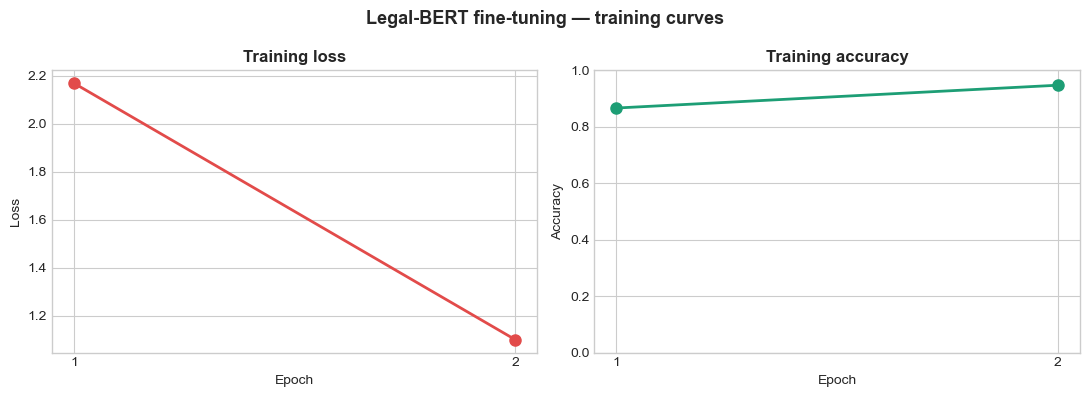

Model saved → cuad_project/models/legal_bert_cuad.pt
Tokenizer saved → cuad_project/models/legal_bert_cuad/

Step 7 complete.
Final training loss     : 1.1007
Final training accuracy : 0.9473


In [32]:
# Plot training loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(1, CONFIG['epochs']+1), train_losses, 
             'o-', color='#E24B4A', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training loss', fontweight='bold')
axes[0].set_xticks(range(1, CONFIG['epochs']+1))

axes[1].plot(range(1, CONFIG['epochs']+1), train_accs,
             'o-', color='#1D9E75', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training accuracy', fontweight='bold')
axes[1].set_xticks(range(1, CONFIG['epochs']+1))
axes[1].set_ylim(0, 1)

plt.suptitle('Legal-BERT fine-tuning — training curves', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/training_curves.png", 
            dpi=150, bbox_inches='tight')
plt.show()

# Save model
model_save_path = f"{CONFIG['model_dir']}/legal_bert_cuad"
torch.save(model.state_dict(), f"{model_save_path}.pt")
tokenizer.save_pretrained(model_save_path)

print(f"Model saved → {model_save_path}.pt")
print(f"Tokenizer saved → {model_save_path}/")
print(f"\nStep 7 complete.")
print(f"Final training loss     : {train_losses[-1]:.4f}")
print(f"Final training accuracy : {train_accs[-1]:.4f}")

## Step 8: Approach B — TF-IDF Retrieval-Assisted Chunking

Approach A ran the model on ALL chunks of every contract.
Approach B is smarter — before running the model, we use TF-IDF 
to pre-filter and retrieve only the TOP-5 most relevant chunks.

Hypothesis: fewer but better chunks → higher precision, similar recall.

Key difference:
- Approach A: model sees ~52 chunks per contract
- Approach B: model sees only top-5 chunks per contract
- Same trained model, no retraining needed

build TF-IDF retrieval

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve_top_k_chunks(context, question, tokenizer, 
                           k=5, max_length=512, stride=128):
    """
    1. Chunk the contract into 512-token windows
    2. Use TF-IDF cosine similarity to rank chunks by relevance to question
    3. Return only top-k most relevant chunks
    """
    # Step 1: create all chunks (decode to text for TF-IDF)
    encoding = tokenizer(
        question,
        context,
        max_length=max_length,
        stride=stride,
        truncation="only_second",
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )
    
    n_chunks = len(encoding["input_ids"])
    
    # Decode each chunk's context portion back to text for TF-IDF
    chunk_texts = []
    for i in range(n_chunks):
        decoded = tokenizer.decode(
            encoding["input_ids"][i], 
            skip_special_tokens=True
        )
        chunk_texts.append(decoded)
    
    if len(chunk_texts) <= k:
        # Contract small enough — return all chunks
        return list(range(n_chunks)), encoding
    
    # Step 2: TF-IDF ranking
    all_texts  = [question] + chunk_texts
    vectorizer = TfidfVectorizer(
        max_features=5000, 
        stop_words='english',
        ngram_range=(1, 2)
    )
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    
    query_vec   = tfidf_matrix[0]        # question vector
    chunk_vecs  = tfidf_matrix[1:]       # chunk vectors
    
    scores = cosine_similarity(query_vec, chunk_vecs).flatten()
    
    # Step 3: get top-k indices
    top_k_indices = np.argsort(scores)[::-1][:k]
    top_k_indices = sorted(top_k_indices.tolist())  # keep original order
    
    return top_k_indices, encoding


# Test on one example
row = test_sel.iloc[10]
top_indices, enc = retrieve_top_k_chunks(
    context=row['context'],
    question=row['question'],
    tokenizer=tokenizer,
    k=5,
)

total_chunks = len(enc["input_ids"])
print(f"TF-IDF retrieval test:")
print(f"  Clause     : {row['clause_type']}")
print(f"  Total chunks in contract : {total_chunks}")
print(f"  Chunks after TF-IDF top-5: {len(top_indices)}")
print(f"  Selected chunk indices   : {top_indices}")
print(f"  Reduction: {total_chunks} → {len(top_indices)} chunks "
      f"({100*len(top_indices)/total_chunks:.1f}% of original)")

TF-IDF retrieval test:
  Clause     : Termination For Convenience
  Total chunks in contract : 9
  Chunks after TF-IDF top-5: 5
  Selected chunk indices   : [3, 5, 6, 7, 8]
  Reduction: 9 → 5 chunks (55.6% of original)


run Approach B on test set

In [38]:
def evaluate_approach_b(model, df, tokenizer, device, 
                         k=5, max_length=512, stride=128):
    """
    For each contract in df:
    1. Retrieve top-k chunks using TF-IDF
    2. Run model only on those k chunks
    3. Predict label = 1 if ANY of the k chunks predicts positive
    """
    model.eval()
    all_labels = []
    all_preds  = []
    all_probs  = []
    
    for _, row in tqdm(df.iterrows(), total=len(df), 
                       desc="Approach B inference"):
        
        true_label = row['label']
        
        # Get top-k chunk indices
        top_indices, encoding = retrieve_top_k_chunks(
            context=row['context'],
            question=row['question'],
            tokenizer=tokenizer,
            k=k,
        )
        
        # Run model on each selected chunk
        chunk_probs = []
        for idx in top_indices:
            input_ids = torch.tensor(
                [encoding["input_ids"][idx]], dtype=torch.long
            ).to(device)
            attention_mask = torch.tensor(
                [encoding["attention_mask"][idx]], dtype=torch.long
            ).to(device)
            
            with torch.no_grad():
                outputs = model(input_ids=input_ids, 
                               attention_mask=attention_mask)
                prob = torch.softmax(
                    outputs["clf_logits"], dim=-1
                )[0, 1].item()
                chunk_probs.append(prob)
        
        # Final prediction: max probability across top-k chunks
        max_prob  = max(chunk_probs) if chunk_probs else 0.0
        pred      = 1 if max_prob > 0.5 else 0
        
        all_labels.append(true_label)
        all_preds.append(pred)
        all_probs.append(max_prob)
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


print("Running Approach B on test set...")
print("Evaluates at CONTRACT level (not chunk level)")
print("Each contract: retrieve top-5 chunks → run model → take max score")
print("This takes ~5-10 minutes...\n")

labels_b, preds_b, probs_b = evaluate_approach_b(
    model, test_sel, tokenizer, device, k=5
)

# Metrics
f1_b   = f1_score(labels_b, preds_b, average='binary')
aupr_b = average_precision_score(labels_b, probs_b)

print(f"\n{'='*50}")
print(f"RESULTS — Approach B (TF-IDF Retrieval)")
print(f"{'='*50}")
print(f"  F1 (binary) : {f1_b:.4f}")
print(f"  AUPR        : {aupr_b:.4f}")
print(f"\nClassification report:")
print(classification_report(
    labels_b, preds_b,
    target_names=["No clause", "Clause present"]
))

Running Approach B on test set...
Evaluates at CONTRACT level (not chunk level)
Each contract: retrieve top-5 chunks → run model → take max score
This takes ~5-10 minutes...



Approach B inference: 100%|██████████| 816/816 [02:28<00:00,  5.48it/s]


RESULTS — Approach B (TF-IDF Retrieval)
  F1 (binary) : 0.7216
  AUPR        : 0.8257

Classification report:
                precision    recall  f1-score   support

     No clause       0.83      0.87      0.85       513
Clause present       0.75      0.69      0.72       303

      accuracy                           0.80       816
     macro avg       0.79      0.78      0.78       816
  weighted avg       0.80      0.80      0.80       816



 per-clause Approach B results

In [39]:
print("="*60)
print("PER-CLAUSE — Approach B (TF-IDF Retrieval)")
print("="*60)

clause_results_b = {}

for clause in CONFIG['selected_clauses']:
    sub = test_sel[test_sel['clause_type'] == clause].reset_index(drop=True)
    
    labels_c, preds_c, probs_c = evaluate_approach_b(
        model, sub, tokenizer, device, k=5
    )
    
    f1_c   = f1_score(labels_c, preds_c, average='binary', zero_division=0)
    aupr_c = average_precision_score(labels_c, probs_c) if labels_c.sum() > 0 else 0.0
    
    clause_results_b[clause] = {"f1": f1_c, "aupr": aupr_c}
    print(f"  {clause:<40} F1={f1_c:.3f}  AUPR={aupr_c:.3f}")

mean_f1_b   = np.mean([v['f1']   for v in clause_results_b.values()])
mean_aupr_b = np.mean([v['aupr'] for v in clause_results_b.values()])
print(f"\n  {'MEAN (Approach B)':<40} F1={mean_f1_b:.3f}  AUPR={mean_aupr_b:.3f}")

PER-CLAUSE — Approach B (TF-IDF Retrieval)


Approach B inference: 100%|██████████| 102/102 [00:17<00:00,  5.69it/s]


  Termination For Convenience              F1=0.675  AUPR=0.792


Approach B inference: 100%|██████████| 102/102 [00:17<00:00,  5.69it/s]


  Governing Law                            F1=0.849  AUPR=0.978


...

  License Grant                            F1=0.707  AUPR=0.911


Approach B inference: 100%|██████████| 102/102 [00:18<00:00,  5.58it/s]


  Non-Compete                              F1=0.511  AUPR=0.576


Approach B inference: 100%|██████████| 102/102 [00:17<00:00,  5.70it/s]

  Warranty Duration                        F1=0.667  AUPR=0.646

  MEAN (Approach B)                        F1=0.688  AUPR=0.788


 final comparison table A vs B

In [40]:
print("\n")
print("="*75)
print("FINAL COMPARISON — Approach A (Sliding Window) vs Approach B (TF-IDF)")
print("="*75)
print(f"{'Clause':<40} {'A F1':>6} {'B F1':>6} {'Winner':>8} │ {'A AUPR':>7} {'B AUPR':>7}")
print("-"*75)

a_wins_f1 = 0
b_wins_f1 = 0

for clause in CONFIG['selected_clauses']:
    f1_a   = clause_results[clause]['f1']
    f1_b   = clause_results_b[clause]['f1']
    aupr_a = clause_results[clause]['aupr']
    aupr_b = clause_results_b[clause]['aupr']
    
    if f1_a >= f1_b:
        winner = "A ✓"
        a_wins_f1 += 1
    else:
        winner = "B ✓"
        b_wins_f1 += 1
    
    print(f"  {clause:<38} {f1_a:>6.3f} {f1_b:>6.3f} {winner:>8} │ {aupr_a:>7.3f} {aupr_b:>7.3f}")

print("-"*75)
mean_a_f1   = np.mean([clause_results[c]['f1']   for c in CONFIG['selected_clauses']])
mean_b_f1   = np.mean([clause_results_b[c]['f1'] for c in CONFIG['selected_clauses']])
mean_a_aupr = np.mean([clause_results[c]['aupr']   for c in CONFIG['selected_clauses']])
mean_b_aupr = np.mean([clause_results_b[c]['aupr'] for c in CONFIG['selected_clauses']])

overall_winner = "A ✓" if mean_a_f1 >= mean_b_f1 else "B ✓"
print(f"  {'MEAN':<38} {mean_a_f1:>6.3f} {mean_b_f1:>6.3f} {overall_winner:>8} │ {mean_a_aupr:>7.3f} {mean_b_aupr:>7.3f}")
print(f"\n  Approach A wins on : {a_wins_f1}/8 clauses")
print(f"  Approach B wins on : {b_wins_f1}/8 clauses")

print(f"""
KEY INSIGHT:
Approach A (sliding window) sees ALL chunks — higher recall, more compute.
Approach B (TF-IDF retrieval) sees only TOP-5 — faster inference, 
may miss clauses if TF-IDF retrieves wrong chunks.
The winner tells you which strategy suits legal clause extraction better.
""")



FINAL COMPARISON — Approach A (Sliding Window) vs Approach B (TF-IDF)
Clause                                     A F1   B F1   Winner │  A AUPR  B AUPR
---------------------------------------------------------------------------
  Termination For Convenience             0.485  0.675      B ✓ │   0.600   0.792
  Governing Law                           0.822  0.849      B ✓ │   0.907   0.978
  Audit Rights                            0.554  0.677      B ✓ │   0.579   0.773
  Change Of Control                       0.312  0.635      B ✓ │   0.498   0.718
  Cap On Liability                        0.487  0.786      B ✓ │   0.717   0.909
  License Grant                           0.445  0.707      B ✓ │   0.513   0.911
  Non-Compete                             0.340  0.511      B ✓ │   0.416   0.576
  Warranty Duration                       0.390  0.667      B ✓ │   0.422   0.646
---------------------------------------------------------------------------
  MEAN                                

plot the comparison

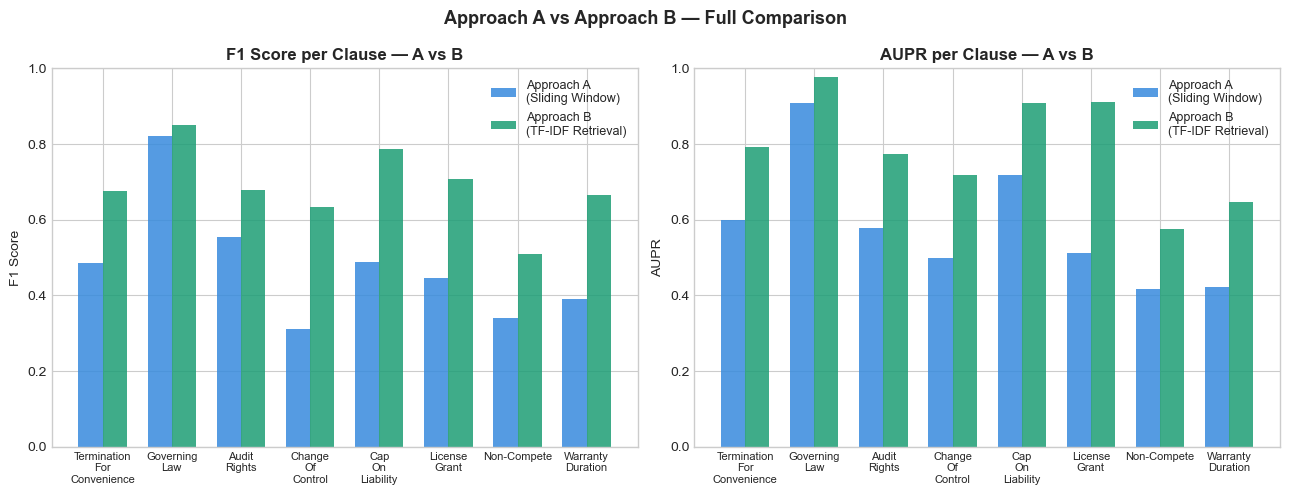

Comparison chart saved.


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clauses_short = [c.replace(' ', '\n') for c in CONFIG['selected_clauses']]
x = np.arange(len(CONFIG['selected_clauses']))
width = 0.35

# F1 comparison
f1_a_vals   = [clause_results[c]['f1']   for c in CONFIG['selected_clauses']]
f1_b_vals   = [clause_results_b[c]['f1'] for c in CONFIG['selected_clauses']]

axes[0].bar(x - width/2, f1_a_vals, width, label='Approach A\n(Sliding Window)',
            color='#378ADD', alpha=0.85)
axes[0].bar(x + width/2, f1_b_vals, width, label='Approach B\n(TF-IDF Retrieval)',
            color='#1D9E75', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(clauses_short, fontsize=8)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score per Clause — A vs B', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1)

# AUPR comparison
aupr_a_vals   = [clause_results[c]['aupr']   for c in CONFIG['selected_clauses']]
aupr_b_vals   = [clause_results_b[c]['aupr'] for c in CONFIG['selected_clauses']]

axes[1].bar(x - width/2, aupr_a_vals, width, label='Approach A\n(Sliding Window)',
            color='#378ADD', alpha=0.85)
axes[1].bar(x + width/2, aupr_b_vals, width, label='Approach B\n(TF-IDF Retrieval)',
            color='#1D9E75', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(clauses_short, fontsize=8)
axes[1].set_ylabel('AUPR')
axes[1].set_title('AUPR per Clause — A vs B', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)

plt.suptitle('Approach A vs Approach B — Full Comparison',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/approach_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved.")

## Step 10: Span Extraction Evaluation

The model has two heads — classification (does clause exist?) and span extraction (where is it?).
We evaluated classification throughout. Now we evaluate span extraction on positive test examples.

Metrics:
- Exact Match (EM): predicted text = ground truth word for word
- Token F1: word overlap between prediction and ground truth

span extraction evaluation

In [43]:
from collections import Counter

def compute_span_metrics(prediction, ground_truth):
    pred_tokens  = prediction.lower().split()
    truth_tokens = ground_truth.lower().split()
    exact_match  = int(prediction.lower().strip() == ground_truth.lower().strip())
    common       = Counter(pred_tokens) & Counter(truth_tokens)
    num_common   = sum(common.values())
    if num_common == 0:
        return exact_match, 0.0
    precision = num_common / len(pred_tokens) if pred_tokens else 0
    recall    = num_common / len(truth_tokens) if truth_tokens else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return exact_match, f1

def extract_span_from_chunk(model, tokenizer, question, context_chunk, device):
    encoding = tokenizer(
        question, context_chunk,
        max_length=512, truncation="only_second",
        padding="max_length", return_tensors="pt",
    )
    input_ids      = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    with torch.no_grad():
        outputs      = model(input_ids=input_ids, attention_mask=attention_mask)
        clf_prob     = torch.softmax(outputs["clf_logits"], dim=-1)[0, 1].item()
        start_idx    = torch.argmax(outputs["start_logits"][0]).item()
        end_idx      = torch.argmax(outputs["end_logits"][0]).item()
        if end_idx < start_idx:
            end_idx = start_idx
    predicted_ids  = encoding["input_ids"][0][start_idx:end_idx+1]
    predicted_text = tokenizer.decode(predicted_ids, skip_special_tokens=True)
    return {"clf_prob": clf_prob, "predicted_text": predicted_text}

# Only run on positive examples
test_pos = test_sel[test_sel['label'] == 1].reset_index(drop=True)
print(f"Evaluating span extraction on {len(test_pos)} positive test contracts...")

span_records = []
for _, row in tqdm(test_pos.iterrows(), total=len(test_pos), desc="Span extraction"):
    ground_truth = row['answers'][0]['text']
    question     = row['question']
    top_indices, encoding = retrieve_top_k_chunks(
        context=row['context'], question=question,
        tokenizer=tokenizer, k=5,
    )
    best_prob = 0.0
    best_span = ""
    for idx in top_indices:
        chunk_text = tokenizer.decode(encoding["input_ids"][idx], skip_special_tokens=True)
        result = extract_span_from_chunk(model, tokenizer, question, chunk_text, device)
        if result["clf_prob"] > best_prob:
            best_prob = result["clf_prob"]
            best_span = result["predicted_text"]
    em, tok_f1 = compute_span_metrics(best_span, ground_truth)
    span_records.append({
        "clause_type"  : row['clause_type'],
        "ground_truth" : ground_truth,
        "prediction"   : best_span,
        "confidence"   : best_prob,
        "exact_match"  : em,
        "token_f1"     : tok_f1,
    })

span_df = pd.DataFrame(span_records)

print(f"\n{'='*55}")
print(f"SPAN EXTRACTION RESULTS (Approach B, positive examples)")
print(f"{'='*55}")
print(f"  Overall Exact Match : {span_df['exact_match'].mean():.4f}")
print(f"  Overall Token F1    : {span_df['token_f1'].mean():.4f}")
print(f"\nPer clause:")
for clause in CONFIG['selected_clauses']:
    sub = span_df[span_df['clause_type'] == clause]
    if len(sub) == 0:
        continue
    print(f"  {clause:<40} EM={sub['exact_match'].mean():.3f}  "
          f"TokenF1={sub['token_f1'].mean():.3f}  n={len(sub)}")

Evaluating span extraction on 303 positive test contracts...


Span extraction: 100%|██████████| 303/303 [01:12<00:00,  4.19it/s]


SPAN EXTRACTION RESULTS (Approach B, positive examples)
  Overall Exact Match : 0.1254
  Overall Token F1    : 0.5099

Per clause:
  Termination For Convenience              EM=0.034  TokenF1=0.671  n=29
  Governing Law                            EM=0.349  TokenF1=0.691  n=83
  Audit Rights                             EM=0.026  TokenF1=0.337  n=38
  Change Of Control                        EM=0.038  TokenF1=0.361  n=26
  Cap On Liability                         EM=0.114  TokenF1=0.554  n=44
  License Grant                            EM=0.020  TokenF1=0.435  n=50
  Non-Compete                              EM=0.000  TokenF1=0.262  n=23
  Warranty Duration                        EM=0.000  TokenF1=0.333  n=10


show predicted vs actual spans

In [44]:
print("="*65)
print("SPAN EXAMPLES — Predicted vs Actual")
print("="*65)

for clause in CONFIG['selected_clauses'][:4]:  # show 4 clauses
    sub = span_df[span_df['clause_type'] == clause]
    if len(sub) == 0:
        continue
    row = sub.loc[sub['token_f1'].idxmax()]  # best prediction
    print(f"\nClause     : {clause}")
    print(f"Token F1   : {row['token_f1']:.3f}  |  Exact Match: {'YES ✅' if row['exact_match'] else 'NO ❌'}")
    print(f"Ground truth : \"{row['ground_truth'][:180]}\"")
    print(f"Prediction   : \"{row['prediction'][:180]}\"")
    print("-"*65)

SPAN EXAMPLES — Predicted vs Actual

Clause     : Termination For Convenience
Token F1   : 1.000  |  Exact Match: YES ✅
Ground truth : "The Company may terminate this Agreement and the engagement of the Contractor without Cause at any time on 30 days prior written notice."
Prediction   : "the company may terminate this agreement and the engagement of the contractor without cause at any time on 30 days prior written notice."
-----------------------------------------------------------------

Clause     : Governing Law
Token F1   : 1.000  |  Exact Match: YES ✅
Ground truth : "This Agreement was entered into in the State of Florida, and its validity, construction, interpretation, and legal effect shall be governed by the laws and judicial decisions of th"
Prediction   : "this agreement was entered into in the state of florida, and its validity, construction, interpretation, and legal effect shall be governed by the laws and judicial decisions of th"
----------------------------------------

## Step 11: Error Analysis

We examine where and why the model fails.
Three error types we care about:
- False Negatives: clause exists but model missed it (bad recall)
- False Positives: no clause but model predicted one (bad precision)
- Which clauses are hardest and why

Error analysis: 100%|██████████| 816/816 [03:31<00:00,  3.86it/s]



Error breakdown:
error_type
True Negative     444
True Positive     210
False Negative     93
False Positive     69


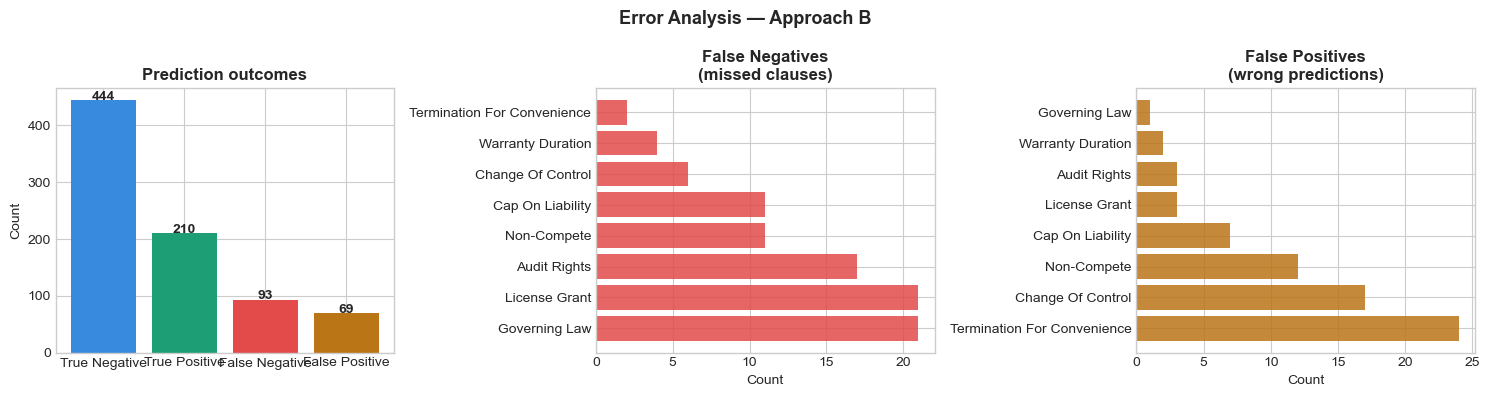

Error analysis chart saved.


In [45]:
print("Collecting error analysis from Approach B predictions...")

error_records = []
for _, row in tqdm(test_sel.iterrows(), total=len(test_sel), desc="Error analysis"):
    true_label  = row['label']
    clause_type = row['clause_type']
    top_indices, encoding = retrieve_top_k_chunks(
        context=row['context'], question=row['question'],
        tokenizer=tokenizer, k=5,
    )
    chunk_probs = []
    for idx in top_indices:
        input_ids = torch.tensor([encoding["input_ids"][idx]], dtype=torch.long).to(device)
        attention_mask = torch.tensor([encoding["attention_mask"][idx]], dtype=torch.long).to(device)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            prob = torch.softmax(outputs["clf_logits"], dim=-1)[0, 1].item()
            chunk_probs.append(prob)
    max_prob   = max(chunk_probs) if chunk_probs else 0.0
    pred_label = 1 if max_prob > 0.5 else 0
    if true_label == 1 and pred_label == 0:
        error_type = "False Negative"
    elif true_label == 0 and pred_label == 1:
        error_type = "False Positive"
    elif true_label == 1 and pred_label == 1:
        error_type = "True Positive"
    else:
        error_type = "True Negative"
    error_records.append({
        "clause_type": clause_type,
        "true_label" : true_label,
        "pred_label" : pred_label,
        "confidence" : max_prob,
        "error_type" : error_type,
        "context_len": row['context_len'],
    })

errors_df = pd.DataFrame(error_records)

print(f"\nError breakdown:")
print(errors_df['error_type'].value_counts().to_string())

# Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

error_counts = errors_df['error_type'].value_counts()
colors_map = {'True Positive':'#1D9E75','True Negative':'#378ADD',
              'False Negative':'#E24B4A','False Positive':'#BA7517'}
colors = [colors_map[e] for e in error_counts.index]
axes[0].bar(error_counts.index, error_counts.values, color=colors)
axes[0].set_title('Prediction outcomes', fontweight='bold')
axes[0].set_ylabel('Count')
for i, val in enumerate(error_counts.values):
    axes[0].text(i, val+1, str(val), ha='center', fontweight='bold')

fn_by_clause = errors_df[errors_df['error_type']=='False Negative']['clause_type'].value_counts()
axes[1].barh(fn_by_clause.index, fn_by_clause.values, color='#E24B4A', alpha=0.85)
axes[1].set_title('False Negatives\n(missed clauses)', fontweight='bold')
axes[1].set_xlabel('Count')

fp_by_clause = errors_df[errors_df['error_type']=='False Positive']['clause_type'].value_counts()
axes[2].barh(fp_by_clause.index, fp_by_clause.values, color='#BA7517', alpha=0.85)
axes[2].set_title('False Positives\n(wrong predictions)', fontweight='bold')
axes[2].set_xlabel('Count')

plt.suptitle('Error Analysis — Approach B', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/error_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Error analysis chart saved.")

interactive test function

In [46]:
def test_contract(contract_text, clause_type, model, tokenizer, device, k=5):
    question  = (f'Highlight the parts (if any) of this contract related to '
                 f'"{clause_type}" that should be reviewed by a lawyer.')
    print("="*65)
    print(f"CLAUSE TYPE    : {clause_type}")
    print(f"CONTRACT LENGTH: {len(contract_text.split())} words")
    print("="*65)

    # Approach A — all chunks
    encoding_a = tokenizer(
        question, contract_text, max_length=512, stride=128,
        truncation="only_second", return_overflowing_tokens=True,
        padding="max_length",
    )
    best_prob_a, best_span_a = 0.0, ""
    for i in range(len(encoding_a["input_ids"])):
        chunk = tokenizer.decode(encoding_a["input_ids"][i], skip_special_tokens=True)
        res   = extract_span_from_chunk(model, tokenizer, question, chunk, device)
        if res["clf_prob"] > best_prob_a:
            best_prob_a = res["clf_prob"]
            best_span_a = res["predicted_text"]

    # Approach B — TF-IDF top-5
    top_indices, encoding_b = retrieve_top_k_chunks(
        context=contract_text, question=question, tokenizer=tokenizer, k=k
    )
    best_prob_b, best_span_b = 0.0, ""
    for idx in top_indices:
        chunk = tokenizer.decode(encoding_b["input_ids"][idx], skip_special_tokens=True)
        res   = extract_span_from_chunk(model, tokenizer, question, chunk, device)
        if res["clf_prob"] > best_prob_b:
            best_prob_b = res["clf_prob"]
            best_span_b = res["predicted_text"]

    pred_a = "YES ✅" if best_prob_a >= 0.5 else "NO ❌"
    pred_b = "YES ✅" if best_prob_b >= 0.5 else "NO ❌"

    print(f"\n{'':25} {'Approach A':>18} {'Approach B':>18}")
    print(f"{'Clause present?':<25} {pred_a:>18} {pred_b:>18}")
    print(f"{'Confidence':<25} {best_prob_a:>18.4f} {best_prob_b:>18.4f}")
    print(f"{'Chunks evaluated':<25} {len(encoding_a['input_ids']):>18} {len(top_indices):>18}")

    if best_prob_a >= 0.5:
        print(f"\nApproach A extracted: \"{best_span_a[:200]}\"")
    if best_prob_b >= 0.5:
        print(f"Approach B extracted: \"{best_span_b[:200]}\"")

    agree = (best_prob_a >= 0.5) == (best_prob_b >= 0.5)
    print(f"\nModels agree: {'YES ✅' if agree else 'NO ⚠️ models disagree'}")

print("test_contract() ready.")
print(f"\nAvailable clause types:")
for i, c in enumerate(CONFIG['selected_clauses'], 1):
    print(f"  {i}. {c}")

test_contract() ready.

Available clause types:
  1. Termination For Convenience
  2. Governing Law
  3. Audit Rights
  4. Change Of Control
  5. Cap On Liability
  6. License Grant
  7. Non-Compete
  8. Warranty Duration


test on a real contract

In [53]:
# Test on a real contract from test set with known Governing Law clause
real_row = test_sel[
    (test_sel['clause_type'] == 'Governing Law') &
    (test_sel['label'] == 1)
].iloc[0]

print(f"Contract : {real_row['contract']}")
print(f"Known answer: {real_row['answers'][0]['text'][:120]}\n")

test_contract(real_row['context'], "Governing Law", model, tokenizer, device)

Contract : LohaCompanyltd_20191209_F-1_EX-10.16_11917878_EX-10.16_Supply Agreement
Known answer: It will be governed by the law of the People's Republic of China ,otherwise it is governed by United Nations Convention 

CLAUSE TYPE    : Governing Law
CONTRACT LENGTH: 1880 words

                                  Approach A         Approach B
Clause present?                        YES ✅              YES ✅
Confidence                            0.9941             0.9941
Chunks evaluated                           7                  5

Approach A extracted: "it will be governed by the law of the people ' s republic of china, otherwise it is governed by united nations convention on contract for the international sale of goods."
Approach B extracted: "it will be governed by the law of the people ' s republic of china, otherwise it is governed by united nations convention on contract for the international sale of goods."

Models agree: YES ✅


test your own contract

In [54]:
MY_CONTRACT = """
CONSULTING AGREEMENT

This Agreement is entered into as of January 1, 2024, between TechCorp GmbH
("Company") and DataSolutions Ltd ("Consultant").

1. SERVICES: The Consultant agrees to provide data analytics services.

2. TERMINATION: Either party may terminate this Agreement at any time,
for any reason, upon thirty (30) days prior written notice.

3. LIMITATION OF LIABILITY: In no event shall either party be liable for
indirect or consequential damages. Total liability shall not exceed fees
paid in the three months preceding the claim.

4. GOVERNING LAW: This Agreement shall be governed by the laws of the
State of Delaware, without regard to conflict of law provisions.

5. AUDIT RIGHTS: Company shall have the right, upon reasonable notice,
to audit Consultant's records once per calendar year.
"""

for clause in ["Governing Law", "Termination For Convenience",
               "Cap On Liability", "Audit Rights", "Non-Compete"]:
    test_contract(MY_CONTRACT, clause, model, tokenizer, device)
    print()

CLAUSE TYPE    : Governing Law
CONTRACT LENGTH: 124 words

                                  Approach A         Approach B
Clause present?                        YES ✅              YES ✅
Confidence                            0.9960             0.9960
Chunks evaluated                           1                  1

Approach A extracted: "this agreement shall be governed by the laws of the state of delaware, without regard to conflict of law provisions."
Approach B extracted: "this agreement shall be governed by the laws of the state of delaware, without regard to conflict of law provisions."

Models agree: YES ✅

CLAUSE TYPE    : Termination For Convenience
CONTRACT LENGTH: 124 words

                                  Approach A         Approach B
Clause present?                        YES ✅              YES ✅
Confidence                            0.9853             0.9853
Chunks evaluated                           1                  1

Approach A extracted: "either party may terminate 